<a href="https://colab.research.google.com/github/antonDinkov/AI_integrationsForDev/blob/main/Regular_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Initializing

In [51]:
!pip install -q -U chromadb openai pypdf google-genai elevenlabs pydantic

In [52]:
import base64
import json
import os
import re
import uuid

from pathlib import Path
from typing import Literal

import chromadb

from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction
from elevenlabs import ElevenLabs
from google import genai
from IPython.display import Audio, Image, display
from openai import OpenAI
from pydantic import BaseModel, Field
from pypdf import PdfReader

## API keys and model configuration

In [53]:
from google.colab import userdata


def get_secret(secret_name: str) -> str:
    """
    Read an API key from Google Colab Secrets.

    If the notebook is executed outside Colab, the function tries
    to read the same value from an environment variable.
    """

    value = None

    try:
        value = userdata.get(secret_name)
    except Exception:
        value = os.getenv(secret_name)

    if not value:
        raise RuntimeError(
            f"Missing secret: {secret_name}. "
            "Add it to Google Colab Secrets."
        )

    return value


OPENAI_API_KEY = get_secret("OPEN_AI_API_KEY")
GEMINI_API_KEY = get_secret("Gemini_API_Key")
ELEVENLABS_API_KEY = get_secret("ELEVENLABS_API_KEY")

In [54]:
OPENAI_TEXT_MODEL = "gpt-5.4-nano-2026-03-17"
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"

GEMINI_IMAGE_MODEL = "gemini-3.1-flash-lite-image"

ELEVENLABS_TTS_MODEL = "eleven_flash_v2_5"

ELEVENLABS_VOICE_ID = "zX2tU5GM7OSuYa2xQ0Bc"

PDF_PATH = Path(
    "/content/euclid's_book_on_division_of_figures-pdf.pdf"
)

CHROMA_PATH = "/content/euclid_chroma_database"
COLLECTION_NAME = "euclid_divisions_collection"

CHUNK_SIZE = 1400
CHUNK_OVERLAP = 250
RETRIEVAL_RESULTS_COUNT = 6

MAX_HISTORY_MESSAGES = 8

In [55]:
openai_client = OpenAI(
    api_key=OPENAI_API_KEY
)

gemini_client = genai.Client(
    api_key=GEMINI_API_KEY
)

elevenlabs_client = ElevenLabs(
    api_key=ELEVENLABS_API_KEY
)

print("API clients initialized successfully.")

API clients initialized successfully.


## Extract content from the PDF file

In [56]:
if not PDF_PATH.exists():
    from google.colab import files

    print(
        "Upload the PDF file. The expected filename is:\n"
        f"{PDF_PATH.name}"
    )

    uploaded_files = files.upload()

    if not uploaded_files:
        raise FileNotFoundError(
            "No PDF file was uploaded."
        )

    uploaded_filename = next(iter(uploaded_files))
    PDF_PATH = Path("/content") / uploaded_filename


if PDF_PATH.suffix.lower() != ".pdf":
    raise ValueError(
        "The uploaded source must be a PDF file."
    )

print(f"Using PDF: {PDF_PATH}")

Using PDF: /content/euclid's_book_on_division_of_figures-pdf.pdf


In [57]:
pdf_reader = PdfReader(
    str(PDF_PATH)
)

print(
    f"There are {len(pdf_reader.pages)} pages in total."
)

There are 111 pages in total.


In [58]:
pdf_pages = []

for page_number, page in enumerate(
    pdf_reader.pages,
    start=1
):
    page_text = page.extract_text() or ""

    page_text = re.sub(
        r"\n{3,}",
        "\n\n",
        page_text
    ).strip()

    if page_text:
        pdf_pages.append(
            {
                "page_number": page_number,
                "text": page_text
            }
        )

print(
    f"Successfully extracted text from "
    f"{len(pdf_pages)} pages."
)

Successfully extracted text from 109 pages.


In [59]:
total_characters = sum(
    len(page["text"])
    for page in pdf_pages
)

print(
    f"There are {total_characters:,} "
    "extracted characters in total."
)

There are 203,683 extracted characters in total.


In [60]:
print(
    pdf_pages[0]["text"][:3000]
)

The Project Gutenberg EBook of Euclid’s Book on Divisions of Figures, by
Raymond Clare Archibald
This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever. You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.org
Title: Euclid’s Book on Divisions of Figures
Author: Raymond Clare Archibald
Release Date: January 21, 2012 [EBook #38640]
Language: English
Character set encoding: ISO-8859-1
*** START OF THIS PROJECT GUTENBERG EBOOK EUCLID’S BOOK ON DIVISIONS ***


## Chunk the PDF content

In [61]:
def split_text_into_chunks(
    text: str,
    chunk_size: int = CHUNK_SIZE,
    overlap: int = CHUNK_OVERLAP
) -> list[str]:
    """
    Split text into overlapping chunks.

    Whenever possible, the function moves the end of a chunk
    to a paragraph or sentence boundary.
    """

    if chunk_size <= overlap:
        raise ValueError(
            "The chunk size must be greater than the overlap."
        )

    chunks = []
    start = 0

    while start < len(text):
        proposed_end = min(
            start + chunk_size,
            len(text)
        )

        end = proposed_end

        if proposed_end < len(text):
            boundary_search_start = (
                start + chunk_size // 2
            )

            paragraph_boundary = text.rfind(
                "\n\n",
                boundary_search_start,
                proposed_end
            )

            sentence_boundary = text.rfind(
                ". ",
                boundary_search_start,
                proposed_end
            )

            best_boundary = max(
                paragraph_boundary,
                sentence_boundary
            )

            if best_boundary > start:
                end = best_boundary + 1

        current_chunk = text[start:end].strip()

        if current_chunk:
            chunks.append(current_chunk)

        if end >= len(text):
            break

        start = max(
            end - overlap,
            start + 1
        )

    return chunks

In [62]:
document_chunks = []

for page in pdf_pages:
    page_number = page["page_number"]

    page_chunks = split_text_into_chunks(
        page["text"]
    )

    for chunk_number, chunk_text in enumerate(
        page_chunks,
        start=1
    ):
        document_chunks.append(
            {
                "id": (
                    f"page_{page_number}_"
                    f"chunk_{chunk_number}"
                ),
                "text": chunk_text,
                "metadata": {
                    "source": PDF_PATH.name,
                    "page_number": page_number,
                    "chunk_number": chunk_number
                }
            }
        )

print(
    f"There are {len(document_chunks)} "
    "chunks in total."
)

There are 219 chunks in total.


In [63]:
print(
    document_chunks[0]
)

{'id': 'page_1_chunk_1', 'text': 'The Project Gutenberg EBook of Euclid’s Book on Divisions of Figures, by\nRaymond Clare Archibald\nThis eBook is for the use of anyone anywhere at no cost and with\nalmost no restrictions whatsoever. You may copy it, give it away or\nre-use it under the terms of the Project Gutenberg License included\nwith this eBook or online at www.gutenberg.org\nTitle: Euclid’s Book on Divisions of Figures\nAuthor: Raymond Clare Archibald\nRelease Date: January 21, 2012 [EBook #38640]\nLanguage: English\nCharacter set encoding: ISO-8859-1\n*** START OF THIS PROJECT GUTENBERG EBOOK EUCLID’S BOOK ON DIVISIONS ***', 'metadata': {'source': "euclid's_book_on_division_of_figures-pdf.pdf", 'page_number': 1, 'chunk_number': 1}}


## Setup the Vector Database

In [64]:
embedding_function = OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY,
    model_name=OPENAI_EMBEDDING_MODEL
)

chroma_client = chromadb.PersistentClient(
    path=CHROMA_PATH
)

In [65]:
try:
    chroma_client.delete_collection(
        name=COLLECTION_NAME
    )

    print(
        "The previous Chroma collection was deleted."
    )

except Exception:
    print(
        "No previous Chroma collection was found."
    )

No previous Chroma collection was found.


In [66]:
chroma_collection = (
    chroma_client.create_collection(
        name=COLLECTION_NAME,
        embedding_function=embedding_function,
        metadata={
            "description": (
                "Vector database for Euclid's "
                "Book on Divisions of Figures"
            )
        }
    )
)

In [67]:
batch_size = 100

for start_index in range(
    0,
    len(document_chunks),
    batch_size
):
    batch = document_chunks[
        start_index:
        start_index + batch_size
    ]

    chroma_collection.add(
        ids=[
            item["id"]
            for item in batch
        ],
        documents=[
            item["text"]
            for item in batch
        ],
        metadatas=[
            item["metadata"]
            for item in batch
        ]
    )

print(
    f"There are {chroma_collection.count()} "
    "documents stored in ChromaDB."
)

There are 219 documents stored in ChromaDB.


In [68]:
test_search = chroma_collection.query(
    query_texts=[
        "What is Euclid's Book on Divisions of Figures about?"
    ],
    n_results=3,
    include=[
        "documents",
        "metadatas",
        "distances"
    ]
)

test_search

{'ids': [['page_18_chunk_1', 'page_3_chunk_1', 'page_1_chunk_1']],
 'embeddings': None,
 'documents': [['8 EUCLID’S BOOK ON DIVISION OF FIGURES I [8–9\nattributed to Euclid in the MS. and corresponds to the description of it by\nProclus. Generally speaking, the divisions are divisions into ﬁgures of the same\nkind as the original ﬁgures, e. g. of triangles into triangles; but there are also\ndivisions into ‘unlike’ ﬁgures, e. g. that of a triangle by a straight line parallel to\nthe base. The missing propositions about the division of a circle are also here:\n‘to divide into two equal parts a given ﬁgure bounded by an arc of a circle and\ntwo straight lines including a given angle’ and ‘to draw in a given circle two\nparallel straight lines cutting oﬀ a certain part of a circle.’ Unfortunately the\nproofs are given of only four propositions (including the two last mentioned) out\nof 36, because the Arabian translator found them too easy and omitted them.”\nThat the omission is due to t

## Conversation history

In [69]:
conversation_history = []


def reset_conversation() -> None:
    """
    Remove all messages from the current conversation history.
    """

    conversation_history.clear()

    print(
        "Conversation history has been cleared."
    )


def show_conversation_history() -> None:
    """
    Display all stored conversation messages.
    """

    if not conversation_history:
        print(
            "The conversation history is empty."
        )

        return

    for index, message in enumerate(
        conversation_history,
        start=1
    ):
        print(
            f"{index}. {message['role'].upper()}"
        )

        print(
            message["content"]
        )

        print(
            "-" * 70
        )

## Structured request extraction

In [70]:
class IntermediateResponse(BaseModel):
    prompt: str = Field(
        description=(
            "A standalone question about the PDF document. "
            "It must resolve references such as it, this, "
            "that proposition or the previous answer by using "
            "the conversation history."
        )
    )

    format: Literal[
        "text",
        "image",
        "audio"
    ] = Field(
        description=(
            "The output format requested by the user."
        )
    )

In [71]:
def get_recent_conversation_messages(
    limit: int = MAX_HISTORY_MESSAGES
) -> list[dict]:
    """
    Return the most recent conversation messages.
    """

    return conversation_history[-limit:]

In [72]:
def extract_request_data(
    user_question: str
) -> IntermediateResponse:
    """
    Extract a standalone PDF question and requested output format.

    Recent conversation history is included so the model can
    understand follow-up references such as:

    - it
    - this proposition
    - the previous one
    - explain that again
    """

    if not isinstance(user_question, str):
        raise TypeError(
            "The question must be a string."
        )

    if not user_question.strip():
        raise ValueError(
            "The question cannot be empty."
        )

    input_messages = [
        {
            "role": "developer",
            "content": """
You extract a standalone document question and a requested
response format.

Return exactly two fields:

1. prompt
2. format

The format must be exactly one of:

- text
- image
- audio

Instructions:

1. Use the previous conversation messages to resolve references
   such as "it", "this", "that one", "the previous proposition",
   "explain it again" or similar phrases.

2. The resulting prompt must be a fully standalone question that
   can be understood without seeing the conversation history.

3. Do not answer the user's question.

4. Preserve the meaning of the user's request.

5. Remove presentation instructions from the prompt.

6. Select "image" when the user asks to draw, show, illustrate,
   visualize, create or generate an image or diagram.

7. Select "audio" when the user asks to hear, listen, narrate,
   speak, read aloud or receive an audio answer.

8. Select "text" when the user requests written information or
   does not specify a format.

9. The source document is Euclid's Book on Divisions of Figures.
"""
        }
    ]

    input_messages.extend(
        get_recent_conversation_messages()
    )

    input_messages.append(
        {
            "role": "user",
            "content": user_question
        }
    )

    response = openai_client.responses.parse(
        model=OPENAI_TEXT_MODEL,
        input=input_messages,
        text_format=IntermediateResponse
    )

    if response.output_parsed is None:
        raise RuntimeError(
            "The request could not be converted "
            "to the required structured format."
        )

    return response.output_parsed

## Python tool implementations

In [73]:
def retrieve_information(
    prompt: str
) -> dict:
    """
    Retrieve relevant excerpts from the PDF.

    This function does not use external knowledge.
    It returns only data stored in the vector database.
    """

    if not isinstance(prompt, str):
        raise TypeError(
            "The prompt must be a string."
        )

    if not prompt.strip():
        raise ValueError(
            "The prompt cannot be empty."
        )

    search_results = chroma_collection.query(
        query_texts=[prompt],
        n_results=min(
            RETRIEVAL_RESULTS_COUNT,
            chroma_collection.count()
        ),
        include=[
            "documents",
            "metadatas",
            "distances"
        ]
    )

    retrieved_items = []

    documents = search_results["documents"][0]
    metadatas = search_results["metadatas"][0]
    distances = search_results["distances"][0]

    for document, metadata, distance in zip(
        documents,
        metadatas,
        distances
    ):
        retrieved_items.append(
            {
                "source": metadata["source"],
                "page_number": metadata["page_number"],
                "chunk_number": metadata["chunk_number"],
                "distance": float(distance),
                "text": document
            }
        )

    return {
        "question": prompt,
        "source_document": PDF_PATH.name,
        "results": retrieved_items
    }

In [88]:
def generate_image(
    prompt: str,
    grounded_answer: str
) -> dict:
    """
    Generate an educational image with Gemini.

    The prompt contains only the question and the answer
    that was grounded in the PDF.
    """

    image_instruction = f"""
Create a clear educational illustration based only on the
verified information below from Euclid's Book on Divisions
of Figures.

Document question:

{prompt}

Verified PDF-grounded answer:

{grounded_answer}

Requirements:

- Use only the verified information provided above.
- Do not introduce additional historical facts.
- Do not invent proposition numbers, quotations, names or dates.
- Use a clean academic geometry style.
- Show relevant geometric figures and divisions.
- Prefer a historical mathematical manuscript aesthetic.
- Keep labels short and legible.
- Do not include long paragraphs.
- Do not state that an invented diagram is an original drawing
  from Euclid.
"""

    interaction = gemini_client.interactions.create(
        model=GEMINI_IMAGE_MODEL,
        input=image_instruction,
        response_format={
            "type": "image",
            "mime_type": "image/jpeg",
            "aspect_ratio": "16:9",
            "image_size": "1K"
        }
    )

    output_image = getattr(
        interaction,
        "output_image",
        None
    )

    if (
        output_image is None
        or not getattr(output_image, "data", None)
    ):
        raise RuntimeError(
            "Gemini did not return image data."
        )

    image_bytes = base64.b64decode(
        output_image.data
    )

    image_path = Path(
        f"/content/euclid_image_"
        f"{uuid.uuid4().hex[:8]}.jpeg"
    )

    image_path.write_bytes(
        image_bytes
    )

    return {
        "path": str(image_path),
        "mime_type": "image/jpeg"
    }

In [75]:
def generate_audio(
    grounded_answer: str
) -> dict:
    """
    Convert the PDF-grounded answer to speech with ElevenLabs.
    """

    if (
        not ELEVENLABS_VOICE_ID
        or ELEVENLABS_VOICE_ID
        == "YOUR_ELEVENLABS_VOICE_ID"
    ):
        raise ValueError(
            "Replace YOUR_ELEVENLABS_VOICE_ID "
            "with the ID of a voice available through "
            "your ElevenLabs API plan."
        )

    try:
        audio_stream = (
            elevenlabs_client.text_to_speech.convert(
                voice_id=ELEVENLABS_VOICE_ID,
                model_id=ELEVENLABS_TTS_MODEL,
                text=grounded_answer,
                output_format="mp3_44100_128"
            )
        )

        audio_path = Path(
            f"/content/euclid_audio_"
            f"{uuid.uuid4().hex[:8]}.mp3"
        )

        with audio_path.open("wb") as audio_file:
            for audio_chunk in audio_stream:
                if audio_chunk:
                    audio_file.write(
                        audio_chunk
                    )

        if (
            not audio_path.exists()
            or audio_path.stat().st_size == 0
        ):
            raise RuntimeError(
                "ElevenLabs returned an empty audio file."
            )

        return {
            "path": str(audio_path),
            "mime_type": "audio/mpeg"
        }

    except Exception as error:
        error_text = str(error)

        if (
            "paid_plan_required" in error_text
            or "Free users cannot use library voices"
            in error_text
        ):
            raise RuntimeError(
                "The selected ElevenLabs voice is a "
                "Voice Library voice and cannot be used "
                "through the API on the free plan. "
                "Use a voice created in your own workspace "
                "or upgrade the ElevenLabs plan."
            ) from error

        if "missing_permissions" in error_text:
            raise RuntimeError(
                "The ElevenLabs API key does not have "
                "the required Text-to-Speech permissions."
            ) from error

        raise

## OpenAI function tools

In [27]:
def generate_image(

        raise RuntimeError(
            "Gemini returned an empty response."
        )

    for part in candidate.content.parts:
        if part.inline_data is not None:
            return part.inline_data.data

    raise RuntimeError(
        "Gemini did not return image data."
    )

## Generate audio with ElevenLabs

In [76]:
tools = [
    {
        "type": "function",
        "name": "retrieve_information",
        "description": (
            "Search Euclid's Book on Divisions of Figures "
            "and return relevant excerpts from the PDF. "
            "This tool is the only source of factual "
            "information for answers about the document."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "prompt": {
                    "type": "string",
                    "description": (
                        "A standalone question about the PDF."
                    )
                }
            },
            "required": [
                "prompt"
            ],
            "additionalProperties": False
        },
        "strict": True
    }
]

In [77]:
python_tool_registry = {
    "retrieve_information": retrieve_information,
    "generate_image": generate_image,
    "generate_audio": generate_audio
}

## Tool calling and grounded answer generation

In [78]:
def execute_openai_tool_calls(
    response
) -> list[dict]:
    """
    Execute all function calls returned by the OpenAI model.
    """

    tool_outputs = []

    for output_item in response.output:
        if output_item.type != "function_call":
            continue

        tool_name = output_item.name

        if tool_name not in python_tool_registry:
            raise RuntimeError(
                f"Unknown tool requested: {tool_name}"
            )

        try:
            arguments = json.loads(
                output_item.arguments
            )

        except json.JSONDecodeError as error:
            raise RuntimeError(
                "The model returned invalid tool arguments."
            ) from error

        tool_function = python_tool_registry[
            tool_name
        ]

        tool_result = tool_function(
            **arguments
        )

        tool_outputs.append(
            {
                "type": "function_call_output",
                "call_id": output_item.call_id,
                "output": json.dumps(
                    tool_result,
                    ensure_ascii=False
                )
            }
        )

    return tool_outputs

In [98]:
def get_grounded_answer(
    standalone_prompt: str,
    requested_format: str = "text",
    verbose: bool = True
) -> str:
    """
    Ask OpenAI to call the PDF retrieval tool and then create
    a grounded factual answer using only the returned tool content.
    """

    initial_input = [
        {
            "role": "developer",
            "content": """
You are an assistant for Euclid's Book on Divisions of Figures.

You must use the retrieve_information tool before answering.

The tool output is the only permitted factual source.

Do not answer from memory or external knowledge.
Do not invent missing facts.

If the retrieved excerpts do not provide enough information,
state that the answer could not be established from the
retrieved PDF content.

Answer in the same language as the user's question.
When helpful, cite PDF page numbers included in the tool output.
"""
        },
        {
            "role": "user",
            "content": standalone_prompt
        }
    ]

    first_response = openai_client.responses.create(
        model=OPENAI_TEXT_MODEL,
        input=initial_input,
        tools=tools,
        tool_choice={
            "type": "function",
            "name": "retrieve_information"
        }
    )

    tool_outputs = execute_openai_tool_calls(
        first_response
    )

    if not tool_outputs:
        raise RuntimeError(
            "The model did not call the retrieval tool."
        )

    if verbose:
        print("The retrieve_information tool was called.")

    if requested_format == "image":
        format_instruction = """
The final output will be used only as factual source material
for an external image generation model.

Return a short, plain factual description of what should appear
in the image.

Do not:
- create ASCII art;
- create diagrams with text characters;
- use code blocks;
- claim that an image has already been created;
- say "below is an illustration";
- offer to create another image;
- include poster layouts or decorative borders.

Only summarize the verified visual content that the image
generator should depict.
"""
    elif requested_format == "audio":
        format_instruction = """
The final output will be converted directly to speech.

Write natural spoken prose.

Do not:
- use Markdown tables;
- use code blocks;
- use ASCII art;
- include visual layout instructions;
- include excessive symbols or formatting.

Keep the answer suitable for narration.
"""
    else:
        format_instruction = """
Return a normal written answer.

Do not create ASCII art unless the user explicitly asks for it.
"""

    final_input = initial_input.copy()
    final_input.extend(first_response.output)
    final_input.extend(tool_outputs)

    final_input.append(
        {
            "role": "developer",
            "content": f"""
Now answer using only the information returned by the
retrieve_information tool.

Do not add outside facts.
Do not mention vector embeddings, ChromaDB, tool calls or
internal implementation details.

{format_instruction}
"""
        }
    )

    final_response = openai_client.responses.create(
        model=OPENAI_TEXT_MODEL,
        input=final_input
    )

    answer = final_response.output_text.strip()

    if not answer:
        raise RuntimeError(
            "OpenAI returned an empty answer."
        )

    return answer

## Main ask_ai function

In [99]:
def ask_ai(
    question: str,
    verbose: bool = True
):
    """
    Main document assistant function.

    Processing steps:

    1. Read the current user request.
    2. Use conversation history to resolve references.
    3. Extract the standalone PDF question and output format.
    4. Force an OpenAI tool call to retrieve_information.
    5. Generate a grounded answer from the tool result.
    6. Return text, Gemini image or ElevenLabs audio.
    7. Store the interaction in conversation history.
    """

    request_data = extract_request_data(
        question
    )

    if verbose:
        print(
            "Intermediate structured response:"
        )

        print(
            request_data
        )

        print()

    grounded_answer = get_grounded_answer(
        standalone_prompt=request_data.prompt,
        requested_format=request_data.format,
        verbose=verbose
    )

    if verbose and request_data.format == "text":
        print("\nAnswer retrieved from the PDF:")
        print(grounded_answer)
        print()

    elif verbose and request_data.format == "audio":
        print("\nText prepared for audio:")
        print(grounded_answer)
        print()

    elif verbose and request_data.format == "image":
        print("\nVerified image-generation context:")
        print(grounded_answer)
        print()

    # Store the original user message.
    conversation_history.append(
        {
            "role": "user",
            "content": question
        }
    )

    # Store the textual answer even when the presentation
    # format is image or audio. This allows follow-up questions
    # to refer to the previous answer.
    conversation_history.append(
        {
            "role": "assistant",
            "content": grounded_answer
        }
    )

    if request_data.format == "text":
        print(
            grounded_answer
        )

        return grounded_answer

    if request_data.format == "image":
        image_result = generate_image(
            prompt=request_data.prompt,
            grounded_answer=grounded_answer
        )

        image_path = Path(
            image_result["path"]
        )

        display(
            Image(
                filename=str(image_path)
            )
        )

        print(
            f"Generated image: {image_path}"
        )

        return image_path

    if request_data.format == "audio":
        audio_result = generate_audio(
            grounded_answer=grounded_answer
        )

        audio_path = Path(
            audio_result["path"]
        )

        display(
            Audio(
                filename=str(audio_path),
                autoplay=False
            )
        )

        print(
            f"Generated audio: {audio_path}"
        )

        return audio_path

    raise RuntimeError(
        f"Unsupported response format: "
        f"{request_data.format}"
    )

## Test Case 1 — Text

In [81]:
ask_ai(
    "What is Euclid's Book on Divisions of Figures about? "
    "Give me a text answer."
)

Intermediate structured response:
prompt='What is Euclid’s Book on Divisions of Figures about? Provide a text answer.' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Euclid’s *Book on Divisions of Figures* is concerned with **how to divide geometric figures into parts**—primarily **into figures of the same kind as the original** (e.g., triangles into triangles), but it also includes **divisions into “unlike” figures** (e.g., dividing a triangle by a line parallel to its base). The subject also covers **divisions involving circles**, including propositions about **dividing a circle-bounded figure into two equal parts** and **drawing parallel lines that cut off a certain part of a circle** (as described in the PDF). (pp. 18)

The PDF notes that, in the work’s circle-division material, **proofs are provided for only four propositions out of 36**, with other propositions omitted in a translation process. (p. 18)

Euclid’s *Book on Divisions of Figu

'Euclid’s *Book on Divisions of Figures* is concerned with **how to divide geometric figures into parts**—primarily **into figures of the same kind as the original** (e.g., triangles into triangles), but it also includes **divisions into “unlike” figures** (e.g., dividing a triangle by a line parallel to its base). The subject also covers **divisions involving circles**, including propositions about **dividing a circle-bounded figure into two equal parts** and **drawing parallel lines that cut off a certain part of a circle** (as described in the PDF). (pp. 18)\n\nThe PDF notes that, in the work’s circle-division material, **proofs are provided for only four propositions out of 36**, with other propositions omitted in a translation process. (p. 18)'

## Test Case 2 — Follow-up using conversation history

In [82]:
ask_ai(
    "Explain it more simply."
)

Intermediate structured response:
prompt='Explain, in simpler terms, what Euclid’s Book on Divisions of Figures is about (including that it focuses on dividing geometric shapes into parts, such as dividing triangles or circle-related figures).' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Euclid’s *Book on Divisions of Figures* is about **how to divide geometric figures into parts**—making smaller regions that fit the intended type of division.

- **General idea of the divisions:** it mainly treats **dividing a figure into parts of the same kind as the original**—for example, **dividing triangles into triangles** (p. 18).
- **Also includes “unlike” divisions:** it covers cases where the parts are **not all the same type**, such as **dividing a triangle by a straight line parallel to its base** (p. 18).
- **Includes circle-related problems:** the text also mentions **propositions about dividing figures bounded by arcs**, including:
  - dividin

'Euclid’s *Book on Divisions of Figures* is about **how to divide geometric figures into parts**—making smaller regions that fit the intended type of division.\n\n- **General idea of the divisions:** it mainly treats **dividing a figure into parts of the same kind as the original**—for example, **dividing triangles into triangles** (p. 18).\n- **Also includes “unlike” divisions:** it covers cases where the parts are **not all the same type**, such as **dividing a triangle by a straight line parallel to its base** (p. 18).\n- **Includes circle-related problems:** the text also mentions **propositions about dividing figures bounded by arcs**, including:\n  - dividing such a figure **into two equal parts** using an arc of a circle and two straight lines that include a given angle, and\n  - **drawing two parallel straight lines in a given circle** to cut off a certain part of the circle (p. 18).\n\nThe book is presented as containing **specific propositions**; however, the excerpt notes th

## Test Case 3 — Text

In [83]:
ask_ai(
    "What was Archibald trying to achieve with his restoration? "
    "Answer as text."
)

Intermediate structured response:
prompt='In the PDF excerpt about Euclid’s Book on Divisions of Figures and Archibald’s work, what was Archibald trying to achieve with his restoration?' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Archibald’s restoration was an effort **“to give, with necessary commentary, a restoration of Euclid’s work based on the Woepcke text and on a thirteenth century geometry of Leonardo Pisano”** (p. 8).

Archibald’s restoration was an effort **“to give, with necessary commentary, a restoration of Euclid’s work based on the Woepcke text and on a thirteenth century geometry of Leonardo Pisano”** (p. 8).


'Archibald’s restoration was an effort **“to give, with necessary commentary, a restoration of Euclid’s work based on the Woepcke text and on a thirteenth century geometry of Leonardo Pisano”** (p. 8).'

## Test Case 4 — Follow-up question

In [84]:
ask_ai(
    "Which earlier sources did he use for that?"
)

Intermediate structured response:
prompt='Which earlier sources did Archibald use for his restoration of Euclid’s Book on Divisions of Figures, according to the PDF text?' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
According to the PDF text, Archibald’s restoration was “based on the **Woepcke text**” and on a “thirteenth century geometry of **Leonardo Pisano**” (titled *Practica Geometriae*).  

Relevant excerpts:

- **Woepcke’s text**:  
  “a restoration of Euclid’s work **based on the Woepcke text** and on a thirteenth century geometry of **Leonardo Pisano**.” (p. 8)

- **Leonardo Pisano / Practica Geometriae**:  
  “WITH A RESTORATION BASED ON WOEPCKE’S TEXT AND ON THE **PRACTICA GEOMETRIAE OF LEONARDO PISANO**” (title page; p. 5)

Additionally, Archibald acknowledges early authorities influencing the work’s details (though these are not described as sources for the restoration itself):

- **Heiberg and Heath**:  
  He “acknowledge[s] in

'According to the PDF text, Archibald’s restoration was “based on the **Woepcke text**” and on a “thirteenth century geometry of **Leonardo Pisano**” (titled *Practica Geometriae*).  \n\nRelevant excerpts:\n\n- **Woepcke’s text**:  \n  “a restoration of Euclid’s work **based on the Woepcke text** and on a thirteenth century geometry of **Leonardo Pisano**.” (p. 8)\n\n- **Leonardo Pisano / Practica Geometriae**:  \n  “WITH A RESTORATION BASED ON WOEPCKE’S TEXT AND ON THE **PRACTICA GEOMETRIAE OF LEONARDO PISANO**” (title page; p. 5)\n\nAdditionally, Archibald acknowledges early authorities influencing the work’s details (though these are not described as sources for the restoration itself):\n\n- **Heiberg and Heath**:  \n  He “acknowledge[s] indebtedness” to “Professor J. L. **Heiberg**” and “Sir Thomas L. **Heath**,” noting Heath’s influence “on nearly every page” and that Heiberg sent “proof pages” for Euclid’s *Opera Omnia* references. (p. 9)'

## Test Case 5 — Text

In [85]:
ask_ai(
    "What role does Leonardo Pisano's Practica Geometriae "
    "play in the restoration?"
)

Intermediate structured response:
prompt="What role does Leonardo Pisano's Practica Geometriae play in Archibald’s restoration of Euclid’s Book on Divisions of Figures?" format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Leonardo Pisano’s *Practica Geometriae* plays a key part as **one of the two main bases** for Archibald’s restoration of Euclid’s *Book on Divisions of Figures*—the other basis is **Woepcke’s text** (the title states “WITH A RESTORATION BASED ON WOEPCKE’S TEXT AND ON THE PRACTICA GEOMETRIAE OF LEONARDO PISANO”). (PDF p. 5)

More specifically, Archibald explains that after introducing **Woepcke’s text** as one part of the restoration, the **“other part” requires consideration of the *Practica Geometriae* of Leonardo Pisano**. (PDF p. 19)

In addition, Archibald characterizes Pisano’s work as important because:

- It is **written in 1220** (with the manuscript in the Vatican Library) and later became published (PDF p. 19).
- It conta

'Leonardo Pisano’s *Practica Geometriae* plays a key part as **one of the two main bases** for Archibald’s restoration of Euclid’s *Book on Divisions of Figures*—the other basis is **Woepcke’s text** (the title states “WITH A RESTORATION BASED ON WOEPCKE’S TEXT AND ON THE PRACTICA GEOMETRIAE OF LEONARDO PISANO”). (PDF p. 5)\n\nMore specifically, Archibald explains that after introducing **Woepcke’s text** as one part of the restoration, the **“other part” requires consideration of the *Practica Geometriae* of Leonardo Pisano**. (PDF p. 19)\n\nIn addition, Archibald characterizes Pisano’s work as important because:\n\n- It is **written in 1220** (with the manuscript in the Vatican Library) and later became published (PDF p. 19).\n- It contains **many references to Euclid’s *Elements*** and **many uncredited extracts** from Euclid’s work. (PDF p. 20)\n- From this, Archibald argues that Leonardo must have had **access to some manuscript of Greek or Arabian origin** relevant to Euclid’s ma

## Test Case 6 — Text

In [86]:
ask_ai(
    "What types of geometric figures are divided in "
    "Euclid's treatise? Give me a concise written answer."
)

Intermediate structured response:
prompt='In Euclid’s Book on Divisions of Figures, what types of geometric figures are divided? Provide a concise written answer listing the main figure types (e.g., polygons and circle-related regions).' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
In Euclid’s *Book on Divisions of Figures*, the figures divided are (main types):

- **Triangle** (pages 17–18)  
- **Parallelogram** (pages 17–18)  
- **Trapezium** (pages 17–18)  
- **Quadrilateral** (pages 17–18)  
- **Pentagon** (pages 17–18)  
- **Hexagon** (pages 17–18)  
- **Circle and semicircle** (pages 17–18)  
- A **region bounded by an arc of a circle and two lines** (page 18)

In Euclid’s *Book on Divisions of Figures*, the figures divided are (main types):

- **Triangle** (pages 17–18)  
- **Parallelogram** (pages 17–18)  
- **Trapezium** (pages 17–18)  
- **Quadrilateral** (pages 17–18)  
- **Pentagon** (pages 17–18)  
- **Hexagon** (pages 17–18)  
-

'In Euclid’s *Book on Divisions of Figures*, the figures divided are (main types):\n\n- **Triangle** (pages 17–18)  \n- **Parallelogram** (pages 17–18)  \n- **Trapezium** (pages 17–18)  \n- **Quadrilateral** (pages 17–18)  \n- **Pentagon** (pages 17–18)  \n- **Hexagon** (pages 17–18)  \n- **Circle and semicircle** (pages 17–18)  \n- A **region bounded by an arc of a circle and two lines** (page 18)'

## Test Case 7 — Image

Intermediate structured response:
prompt='Create an educational image that illustrates the types of geometric figures and how they are divided according to Euclid’s treatise on Divisions of Figures.' format='image'

The retrieve_information tool was called.

Verified image-generation context:
Depict a set of geometric figures being divided in the ways described for Euclid’s *Division of Figures*, showing both “like” and “unlike” divisions. Include:

- A triangle partitioned into two equal parts by a line parallel to its base, where the result is one sub-figure labeled as a triangle and the other labeled as a quadrilateral (triangle split by a parallel line). Mark this as an example of division into “unlike” figures (triangle into unlike parts). (Pages 18 and 37.)
- A general visual note that divisions are “divisions into figures of the same kind as the original figures,” with an example arrow such as “triangles into triangles.” (Page 18.)
- A circle example showing a given figure bound

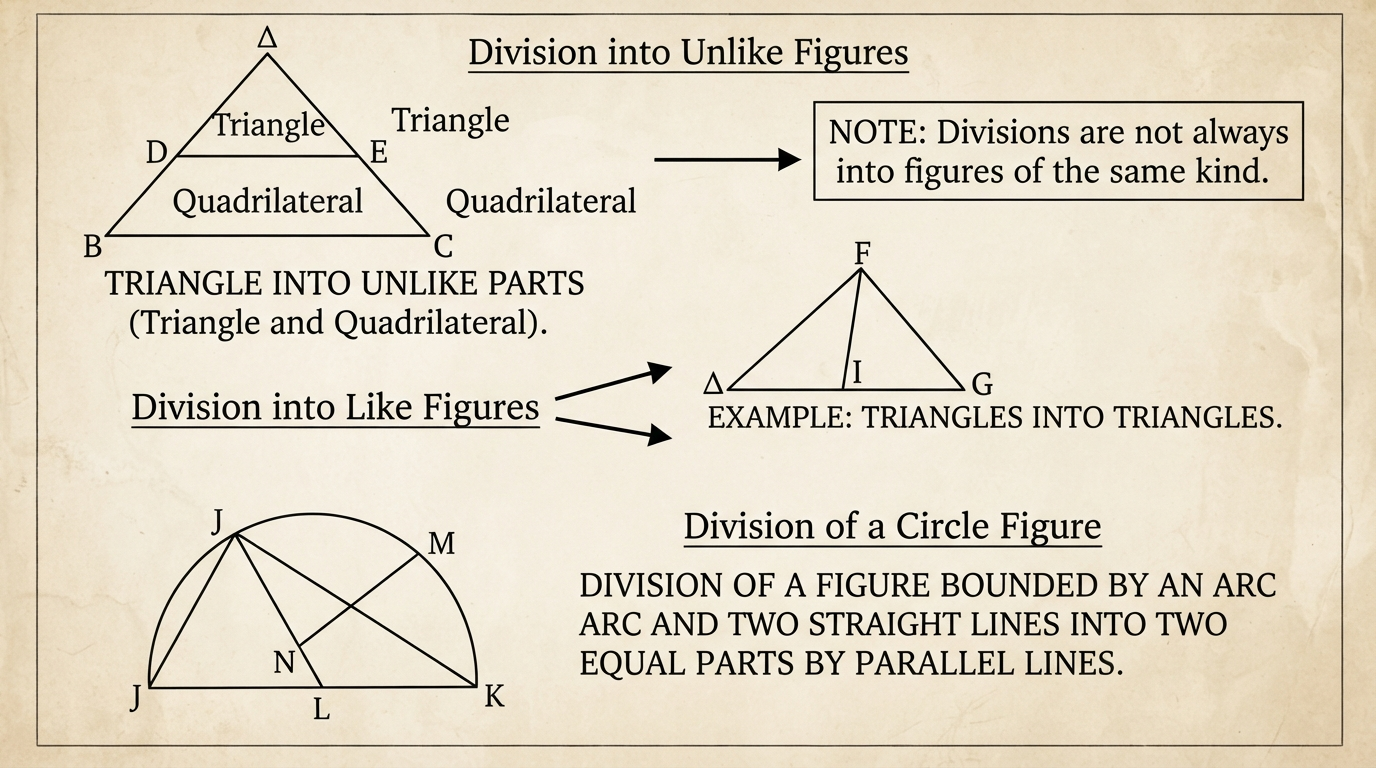

Generated image: /content/euclid_image_a989b15b.jpeg


PosixPath('/content/euclid_image_a989b15b.jpeg')

In [100]:
ask_ai(
    "Create an educational image showing the types of "
    "geometric figures divided in Euclid's treatise."
)

## Test Case 8 — Audio

In [90]:
ask_ai(
    "Read aloud a concise explanation of what "
    "Euclid's Book on Divisions of Figures is about."
)

Intermediate structured response:
prompt='Read aloud a concise explanation of what Euclid’s Book on Divisions of Figures is about.' format='audio'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Euclid’s *Book on Divisions of Figures* is about **dividing given geometric figures into parts**—sometimes **into “like” figures** (e.g., triangles divided into triangles), and sometimes into **“unlike” figures** (e.g., dividing a triangle by a line parallel to its base). It also includes problems about **dividing figures bounded by circular arcs**, such as “to divide into two equal parts a given figure bounded by an arc of a circle and two straight lines including a given angle,” and “to draw in a given circle two parallel straight lines cutting off a certain part of a circle.” (pp. **18**)

According to the document, in the surviving material **proofs are given for only four propositions (out of 36)** because an Arabian translator omitted proofs considered “too easy

Generated audio: /content/euclid_audio_63d02e7d.mp3


PosixPath('/content/euclid_audio_63d02e7d.mp3')

## Test Case 9 — Follow-up audio

In [91]:
ask_ai(
    "Now explain the previous answer in more detail "
    "and return it as audio."
)

Intermediate structured response:
prompt='Provide a more detailed explanation of what Euclid’s Book on Divisions of Figures is about, expanding on the prior answer that said it concerns dividing geometric figures into parts (like and unlike divisions) and includes division problems for regions bounded by circular arcs, with notes that only four propositions out of thirty-six have surviving proofs because an Arabian translator omitted some proofs. Return a detailed explanation suitable for narration.' format='audio'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Euclid’s *Book on Divisions of Figures* is a treatise devoted to the geometric task of **dividing a given figure into parts**, in a way that is systematically described as two main modes:

1. **Dividing into “like” figures**—for example, dividing **triangles into triangles**.  
2. **Dividing into “unlike” figures**—for example, dividing a **triangle by a straight line parallel to its base**, which pro

Generated audio: /content/euclid_audio_8dd87fc8.mp3


PosixPath('/content/euclid_audio_8dd87fc8.mp3')

## Test Case 10 — Additional image

Intermediate structured response:
prompt='Create an educational image that visualizes Euclid’s description (from his Book on Divisions of Figures) of dividing a triangle into two equal parts. Show the specific construction by which the triangle is split into equal-area sub-figures, labeling the original triangle and the resulting two equal parts clearly.' format='image'

The retrieve_information tool was called.

Verified image-generation context:
Depict Euclid’s construction for dividing a given triangle into two equal parts by a line parallel to its base (Proposition 1). Show:

- A triangle labeled **abg** with base **bg** and apex **a**.
- Extend the side **ba** beyond **b** to a point **d** such that **ba = 2ad** (mark **d** on the extension and indicate the condition).
- On segment **ba**, mark a point **e** such that **ba : ae = ae : ad** (indicate the division of **ba** by **e** satisfying the proportion).
- Through **e**, draw a line **ez** parallel to **bg**, meeting the other

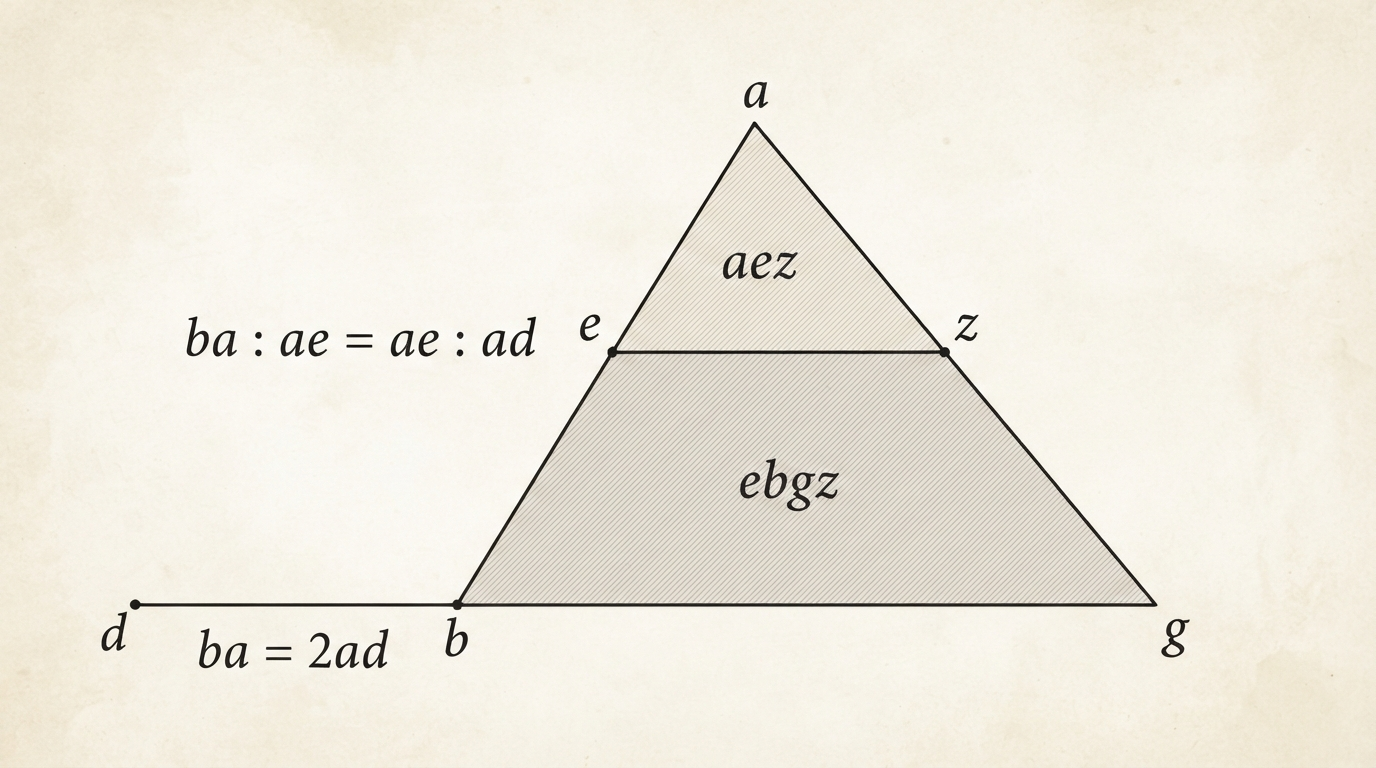

Generated image: /content/euclid_image_e708c51b.jpeg


PosixPath('/content/euclid_image_e708c51b.jpeg')

In [101]:
ask_ai(
    "Visualize the document's description of dividing "
    "a triangle into equal parts."
)

## Inspect conversation history

In [104]:
show_conversation_history()

The conversation history is empty.


## Clear conversation history

In [103]:
reset_conversation()

Conversation history has been cleared.
